# Analysis of Factors Influencing Financial Indicators

**Kurbatov Daniil Evgenevich — БПАД246 — HSE University — April 2026**

Companion notebook to the research project report. Reproduces the empirical case on trading volume and short-term Bitcoin volatility, including the computed numbers, numerical tables, and figures referenced in the report.

**Code-generated tables reproduced here (current report numbering):**
- Table 2 — Descriptive statistics
- Table 3 — Correlations of log volume with volatility proxies
- Table 4 — Stationarity pre-tests (ADF, KPSS)
- Table 6 — Residual diagnostics of the H1 OLS model
- Table 8 — H1 main regression (OLS + Newey–West HAC)
- Table 9 — H1 robustness across four volatility proxies
- Table 10 — H2 Granger predictability at multiple lags
- Table 11 — H3 four-model out-of-sample forecasting

**Report tables written directly in report:**
- Table 1 — Variable definitions
- Table 5 — Model-selection summary
- Table 7 — Hypotheses overview
- Table 12 — Summary of hypothesis-testing results

**Figures produced here (numbering follows the report):**
- Figure 1 — Bitcoin hourly price and trading volume
- Figure 2 — Three hourly volatility proxies
- Figure 3 — Scatter of log volume vs volatility
- Figure 4 — Random Forest feature importance

**Hypotheses tested:**
- H1 (MDH) — contemporaneous volume–volatility association
- H2 (SIAH) — lagged volume helps predict volatility in Granger tests
- H3 — adding volume features gives a small but positive out-of-sample improvement under a fair RF baseline


## Imports and plot settings

In [22]:
import os
import urllib.request
import warnings
import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import pearsonr, spearmanr
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, kpss, grangercausalitytests
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson, jarque_bera

plt.rcParams.update({
    'font.family': 'serif',
    'axes.grid': True,
    'grid.alpha': 0.25,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.dpi': 110,
    'savefig.bbox': 'tight',
})
np.random.seed(42)

## Download the dataset from GitHub

The hourly BTC/USD OHLCV series is hosted in the public GitHub repository  
`simonavoprea/Bitcoin_trading`  
(file `btc-hourly-price_2015_2025.csv`). The cell below downloads it with Python standard-library tools; if the file is already present locally, the download is skipped.

In [23]:
DATA_URL = 'https://raw.githubusercontent.com/simonavoprea/Bitcoin_trading/main/btc-hourly-price_2015_2025.csv'
DATA_FILE = 'btc-hourly-price_2015_2025.csv'

if not os.path.exists(DATA_FILE):
    urllib.request.urlretrieve(DATA_URL, DATA_FILE)
print(f'File size: {os.path.getsize(DATA_FILE)/1e6:.2f} MB')


File size: 6.39 MB


---
## Part 1.1 — Load the data

In [24]:
df = pd.read_csv(DATA_FILE)
# datetime index from date + hour
df['timestamp'] = pd.to_datetime(
    df['DATE_STR'] + ' ' + df['HOUR_STR'].astype(str) + ':00',
    format='%d/%m/%Y %H:%M'
)
df = df.sort_values('timestamp').reset_index(drop=True).set_index('timestamp')
df = df.rename(columns={
    'OPEN_PRICE': 'open',
    'HIGH_PRICE': 'high',
    'LOW_PRICE': 'low',
    'CLOSE_PRICE': 'close',
    'VOLUME_FROM': 'vol_btc',
    'VOLUME_TO': 'vol_usd',
})
print(f'Raw shape: {df.shape}')
print(f'Period:    {df.index.min()}  ->  {df.index.max()}')
print(f'Missing values per column:')
print(df.isnull().sum())
print(f"Duplicates on (date, hour): {df.duplicated(subset=['DATE_STR','HOUR_STR']).sum()}")

Raw shape: (96090, 8)
Period:    2014-11-15 06:00:00  ->  2025-10-31 23:00:00
Missing values per column:
DATE_STR    0
HOUR_STR    0
open        0
high        0
close       0
low         0
vol_btc     0
vol_usd     0
dtype: int64
Duplicates on (date, hour): 0


## Part 1.2 — Feature engineering

In [25]:
# Log return
df['r'] = np.log(df['close'] / df['close'].shift(1))
df['abs_r'] = df['r'].abs()

# Parkinson range volatility (hourly)
df['sigma_P'] = np.sqrt((1/(4*np.log(2))) * (np.log(df['high']/df['low']))**2)

# Garman-Klass; clip the rare negative finite-sample variances to 0
gk_var = 0.5*(np.log(df['high']/df['low']))**2 - (2*np.log(2)-1)*(np.log(df['close']/df['open']))**2
df['sigma_GK'] = np.where(gk_var > 0, np.sqrt(gk_var.clip(lower=0)), 0.0)

# Log volume
df['V_log'] = np.log1p(df['vol_btc'])

# 24h realised vol (annualised)
ANN = np.sqrt(24 * 365)
df['RV_24h'] = df['r'].rolling(24).std() * ANN

# weekly/monthly RV (used in the ML section)
df['RV_w'] = df['RV_24h'].rolling(168).mean()
df['RV_m'] = df['RV_24h'].rolling(720).mean()

# working sample: drop rolling-window NaNs
core = df.dropna(subset=['r','sigma_P','V_log','RV_24h','abs_r']).copy()
gk_clipped_core = int((gk_var.loc[core.index] <= 0).sum())
print(f'Raw rows:               {len(df):,}')
print(f'Core working sample:    {len(core):,}')
print(f'Rows lost to rolling:   {len(df)-len(core):,}')
print(f'Garman-Klass clipped:   {gk_clipped_core:,} rows ({gk_clipped_core/len(core):.2%} of core)')

Raw rows:               96,090
Core working sample:    96,066
Rows lost to rolling:   24
Garman-Klass clipped:   726 rows (0.76% of core)


## Part 1.3 — Outlier diagnostic (3 × IQR, retained only)

In [26]:
def count_iqr_outliers(x, k=3):
    x = x.dropna()
    q1, q3 = np.quantile(x, [.25, .75])
    iqr = q3 - q1
    return int(((x < q1 - k*iqr) | (x > q3 + k*iqr)).sum())

for col, nm in [('r','log return r'), ('sigma_P','Parkinson sigma^P'), ('V_log','log volume V_log')]:
    print(f'{nm:>25s}: {count_iqr_outliers(core[col]):>6,}')

             log return r:  3,563
        Parkinson sigma^P:  2,577
         log volume V_log:    157


## Part 1.4 — Descriptive statistics (Table 2 in the report)


In [27]:
def describe(x):
    #mean, std, min, quartiles, max, skew, excess kurtosis
    x = x.dropna()
    q25, med, q75 = np.quantile(x, [0.25, 0.50, 0.75])
    return (x.mean(), x.std(), x.min(), q25, med, q75, x.max(),
            stats.skew(x), stats.kurtosis(x))

variables = [
    ('Close Price (USD)', core['close']),
    ('Log Return r_t', core['r']),
    ('Volume (BTC)', core['vol_btc']),
    ('Log Volume V_log_t', core['V_log']),
    ('Abs. Return |r_t|', core['abs_r']),
    ('Parkinson sigma^P_t', core['sigma_P']),
    ('Garman-Klass sigma^GK_t', core['sigma_GK']),
    ('Realised Vol. (24h)', core['RV_24h']),
]

print(f'{"Variable":<26s}{"Mean":>11s}{"Std":>11s}{"Min":>10s}{"Q25":>10s}{"Median":>10s}{"Q75":>10s}{"Max":>13s}{"Skew":>8s}{"Kurt":>9s}')

for name, s in variables:
    m, sd, mn, q25, med, q75, mx, sk, kt = describe(s)
    print(f'{name:<26s}{m:>11.4f}{sd:>11.4f}{mn:>10.4f}{q25:>10.4f}{med:>10.4f}{q75:>10.4f}{mx:>13.2f}{sk:>8.2f}{kt:>9.2f}')

Variable                         Mean        Std       Min       Q25    Median       Q75          Max    Skew     Kurt
Close Price (USD)          26218.5953 30886.2604  165.0700 3364.497510709.965041337.4225    126098.78    1.40     1.08
Log Return r_t                 0.0001     0.0076   -0.1668   -0.0024    0.0001    0.0026         0.18   -0.39    32.19
Volume (BTC)                2755.2700 41370.5703    0.1471  792.8675 1460.0050 2705.3725   8410599.90  139.73 23545.92
Log Volume V_log_t             7.2940     0.9523    0.1372    6.6769    7.2869    7.9034        15.95   -0.07     2.10
Abs. Return |r_t|              0.0044     0.0062    0.0000    0.0011    0.0025    0.0053         0.18    5.21    58.70
Parkinson sigma^P_t            0.0053     0.0057    0.0000    0.0024    0.0038    0.0063         0.36   10.75   420.82
Garman-Klass sigma^GK_t        0.0054     0.0058    0.0000    0.0024    0.0039    0.0065         0.42   14.27   727.26
Realised Vol. (24h)            0.5685     0.4226

## Part 1.5 — Correlation of log volume with volatility proxies (Table 3 in the report)


In [28]:
targets = [('abs_r', '|r|'),
           ('sigma_P', 'sigma_P'),
           ('sigma_GK', 'sigma_GK'),
           ('RV_24h', 'RV_24h')]

print(f'{"Measure":>10s}   {"Pearson":>10s}   {"Spearman":>10s}')
for col, nm in targets:
    x = core['V_log']; y = core[col]
    m = ~(x.isna() | y.isna())
    rp, pp = pearsonr(x[m], y[m])
    rs, ps = spearmanr(x[m], y[m])
    print(f'{nm:>10s}   {rp:>+10.3f}   {rs:>+10.3f}')

   Measure      Pearson     Spearman
       |r|       +0.503       +0.490
   sigma_P       +0.601       +0.727
  sigma_GK       +0.582       +0.716
    RV_24h       +0.497       +0.517


## Part 1.6 — Figure 1: Bitcoin price and trading volume

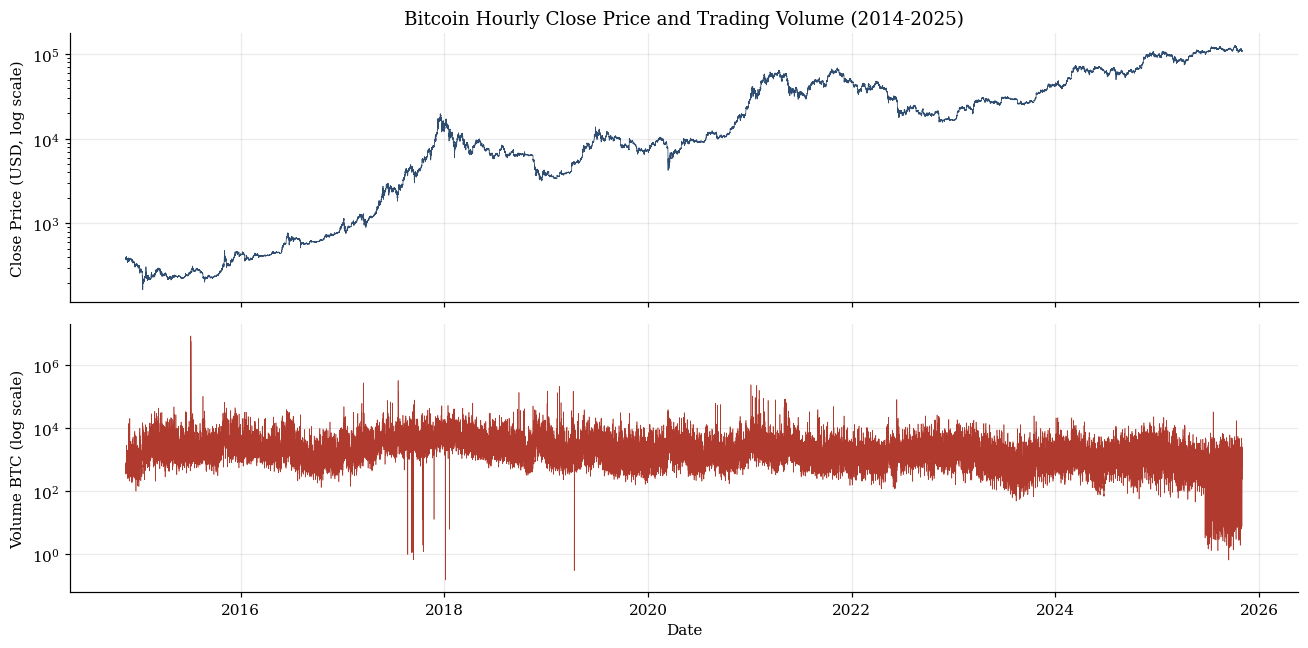

In [29]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(df.index, df['close'], color='#2E4D70', lw=0.5)
axes[0].set_yscale('log')
axes[0].set_ylabel('Close Price (USD, log scale)')
axes[0].set_title('Bitcoin Hourly Close Price and Trading Volume (2014-2025)')

axes[1].plot(df.index, df['vol_btc'].replace(0, np.nan), color='#B03A2E', lw=0.4)
axes[1].set_yscale('log')
axes[1].set_ylabel('Volume BTC (log scale)')
axes[1].set_xlabel('Date')
plt.tight_layout()
plt.savefig('fig1_price_volume.pdf')
plt.show()

## Part 1.7 — Figure 2: Hourly volatility proxies

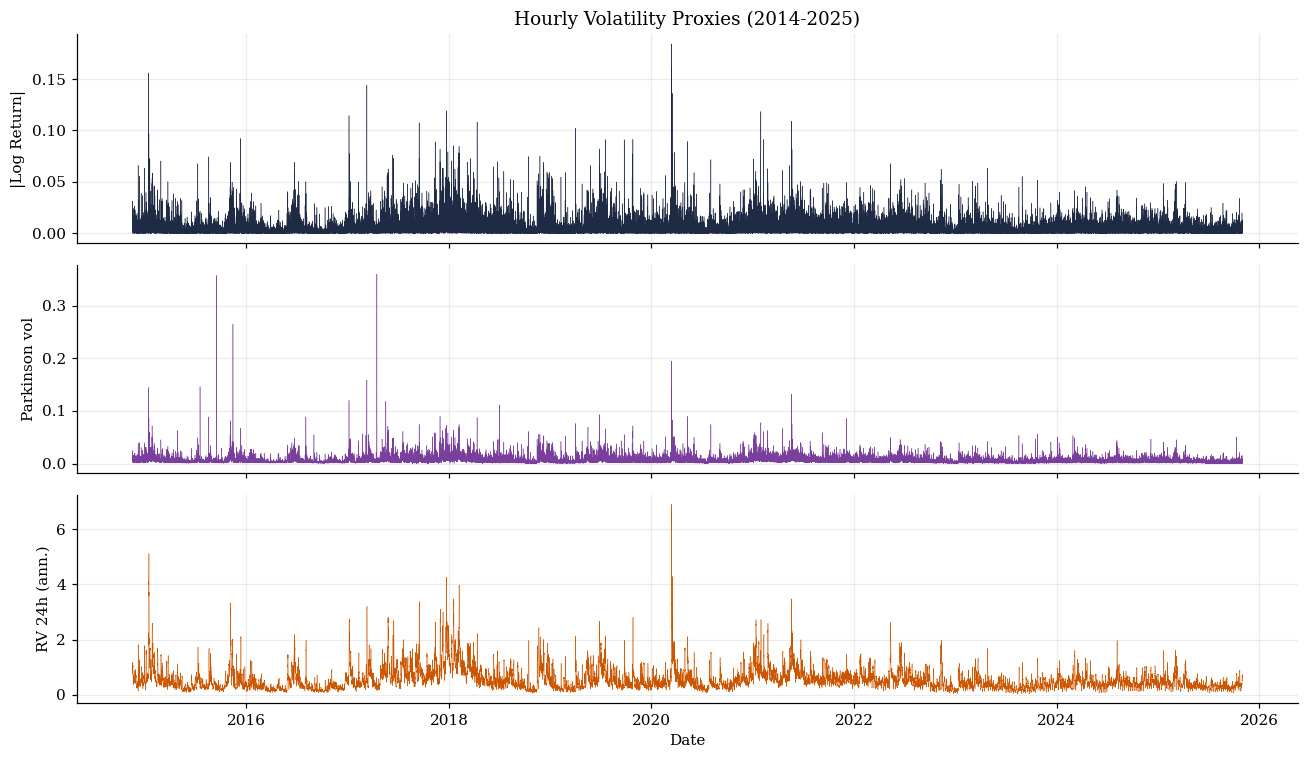

In [30]:
fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)
axes[0].plot(core.index, core['abs_r'], color='#1F2A44', lw=0.3)
axes[0].set_ylabel('|Log Return|')
axes[0].set_title('Hourly Volatility Proxies (2014-2025)')
axes[1].plot(core.index, core['sigma_P'], color='#7A3E9D', lw=0.3)
axes[1].set_ylabel('Parkinson vol')
axes[2].plot(core.index, core['RV_24h'], color='#CC5500', lw=0.3)
axes[2].set_ylabel('RV 24h (ann.)')
axes[2].set_xlabel('Date')
plt.tight_layout()
plt.savefig('fig2_volatility_proxies.pdf')
plt.show()

## Part 1.8 — Figure 3: Scatter of log volume vs volatility (5,000-hour sub-sample)

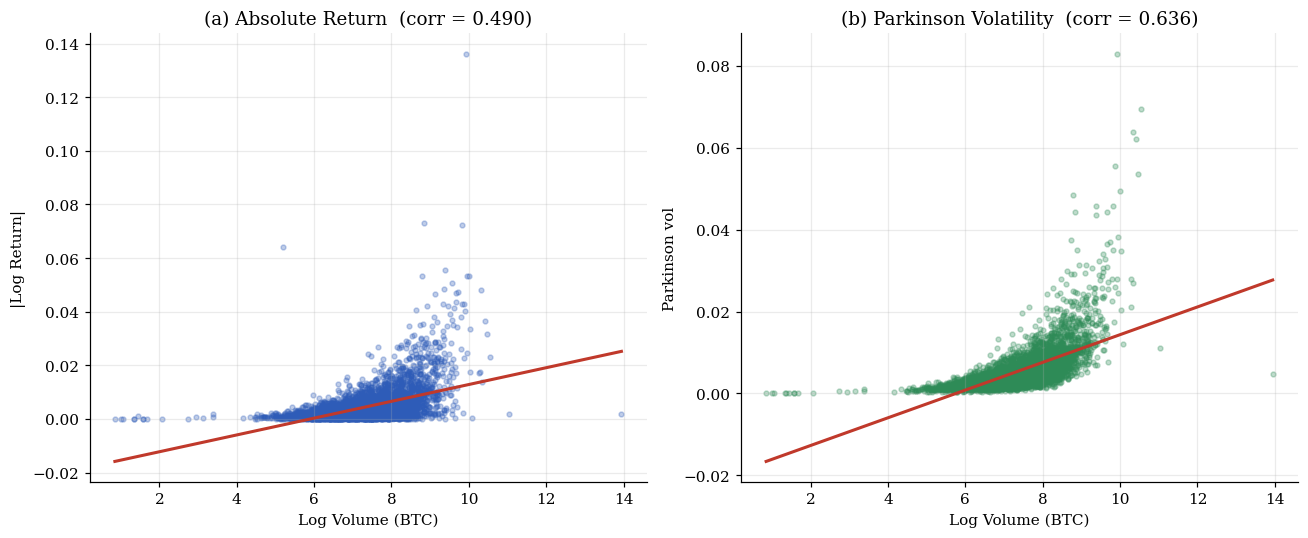

In [31]:
rng = np.random.default_rng(42)
idx = rng.choice(len(core), size=5000, replace=False)
sub = core.iloc[idx]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

#(a) Absolute return
x = sub['V_log'].values; y = sub['abs_r'].values
rho_a = pearsonr(x, y)[0]
axes[0].scatter(x, y, s=10, alpha=0.3, color='#2E5CB8')
coef = np.polyfit(x, y, 1)
xs = np.linspace(x.min(), x.max(), 100)
axes[0].plot(xs, np.polyval(coef, xs), color='#C0392B', lw=2)
axes[0].set_xlabel('Log Volume (BTC)')
axes[0].set_ylabel('|Log Return|')
axes[0].set_title(f'(a) Absolute Return  (corr = {rho_a:.3f})')

#(b) Parkinson
y = sub['sigma_P'].values
rho_b = pearsonr(x, y)[0]
axes[1].scatter(x, y, s=10, alpha=0.3, color='#2E8B57')
coef = np.polyfit(x, y, 1)
axes[1].plot(xs, np.polyval(coef, xs), color='#C0392B', lw=2)
axes[1].set_xlabel('Log Volume (BTC)')
axes[1].set_ylabel('Parkinson vol')
axes[1].set_title(f'(b) Parkinson Volatility  (corr = {rho_b:.3f})')

plt.tight_layout()
plt.savefig('fig3_scatter.pdf')
plt.show()

## Part 1.9 — Stationarity pre-tests (Table 4 in the report)

ADF and KPSS tests on ~10,000 evenly-thinned observations per series. Mixed verdicts (ADF rejects unit-root, KPSS rejects level-stationarity) are common for persistent financial series and motivate the use of Newey–West HAC standard errors in H1.


In [32]:
#ADF (H0: unit root) and KPSS (H0: stationarity), thinned to ~10k points per series
print('Critical values at 5%:  ADF tau = -2.86   |   KPSS eta = 0.463')
print(f'{"Series":>12s}  {"ADF tau":>12s}  {"Verdict":>12s}  {"KPSS eta":>12s}  {"Verdict":>12s}')

with warnings.catch_warnings():
    warnings.simplefilter('ignore')          #KPSS warns past its p-value table
    for col in ['r', 'abs_r', 'sigma_P', 'RV_24h', 'V_log']:
        s = core[col].dropna()
        step = max(1, len(s) // 10000)
        thin = s.iloc[::step].values
        tau = adfuller(thin, maxlag=10, autolag='AIC')[0]
        eta = kpss(thin, regression='c', nlags='legacy')[0]
        adf_v  = 'Stationary' if tau < -2.86 else 'Non-stat.'
        kpss_v = 'Stationary' if eta < 0.463 else 'Non-stat.'
        print(f'{col:>12s}  {tau:>+12.3f}  {adf_v:>12s}  {eta:>12.3f}  {kpss_v:>12s}')

Critical values at 5%:  ADF tau = -2.86   |   KPSS eta = 0.463
      Series       ADF tau       Verdict      KPSS eta       Verdict
           r       -31.930    Stationary         0.239    Stationary
       abs_r       -19.798    Stationary         1.639     Non-stat.
     sigma_P       -17.145    Stationary         1.791     Non-stat.
      RV_24h       -15.321    Stationary         1.958     Non-stat.
       V_log       -13.822    Stationary        11.027     Non-stat.


---
## Part 2 — Hypothesis 1 (MDH): OLS with Newey–West HAC standard errors

$$ \sigma^P_t = \alpha + \beta_1 V^{\log}_t + \beta_2 \sigma^P_{t-1} + \beta_3 |r_{t-1}| + \varepsilon_t $$

- $H_0: \beta_1 = 0$ (volume unrelated to contemporaneous volatility)
- $H_1: \beta_1 \neq 0$ (the MDH-consistent alternative)
- Newey–West HAC bandwidth: $L = \lfloor 4(T/100)^{2/9}\rfloor$ (Newey–West 1994 rule)

In [33]:
#Newey-West HAC standard errors; L=18 from the 4(T/100)^(2/9) rule
HAC_LAGS = 18

def fit_hac(y, X):
    #OLS with Newey-West HAC standard errors
    return sm.OLS(y, sm.add_constant(X)).fit(cov_type='HAC', cov_kwds={'maxlags': HAC_LAGS})

### H1 main regression (Table 8 in the report)

$$ \sigma^P_t = \alpha + \beta_1 V^{\log}_t + \beta_2 \sigma^P_{t-1} + \beta_3 |r_{t-1}| + \varepsilon_t $$

Null hypothesis: $\beta_1 = 0$ (volume does not matter). Estimated with OLS; standard errors are Newey–West HAC with bandwidth $L = 18$ (Newey–West 1994 rule).


In [34]:
core['sigma_P_lag1'] = core['sigma_P'].shift(1)
core['abs_r_lag1'] = core['abs_r'].shift(1)
m = core[['sigma_P', 'V_log', 'sigma_P_lag1', 'abs_r_lag1']].dropna()

# baseline (no volume) vs full
base = fit_hac(m['sigma_P'], m[['sigma_P_lag1', 'abs_r_lag1']])
full = fit_hac(m['sigma_P'], m[['V_log', 'sigma_P_lag1', 'abs_r_lag1']])

print(f'Baseline:  N={int(base.nobs)}  L_HAC={HAC_LAGS}  R2={base.rsquared:.4f}  DW={durbin_watson(base.resid):.3f}')
print(f'  intercept    = {base.params["const"]:+.5f}  (SE {base.bse["const"]:.5f})')
print(f'  sigma_P_lag1 = {base.params["sigma_P_lag1"]:+.5f}  (SE {base.bse["sigma_P_lag1"]:.5f})')
print(f'  |r|_lag1     = {base.params["abs_r_lag1"]:+.5f}  (SE {base.bse["abs_r_lag1"]:.5f})')
print()
print(f'Full H1:   N={int(full.nobs)}  L_HAC={HAC_LAGS}  R2={full.rsquared:.4f}  DW={durbin_watson(full.resid):.3f}')
print(f'  intercept    = {full.params["const"]:+.5f}  (SE {full.bse["const"]:.5f})')
print(f'  V_log        = {full.params["V_log"]:+.5f}  (SE {full.bse["V_log"]:.5f})')
print(f'  sigma_P_lag1 = {full.params["sigma_P_lag1"]:+.5f}  (SE {full.bse["sigma_P_lag1"]:.5f})')
print(f'  |r|_lag1     = {full.params["abs_r_lag1"]:+.5f}  (SE {full.bse["abs_r_lag1"]:.5f})')

ci = full.conf_int().loc['V_log']
print()
print(f'>>> Test statistic on V_log: t = {full.tvalues["V_log"]:+.2f}')
print(f'>>> 95% CI: [{ci[0]:+.5f}, {ci[1]:+.5f}]')
print(f'>>> Delta R2 = {full.rsquared - base.rsquared:+.4f}')
print('>>> Decision: reject H0 (volume matters for contemporaneous volatility)')

Baseline:  N=96065  L_HAC=18  R2=0.2903  DW=2.271
  intercept    = +0.00248  (SE 0.00018)
  sigma_P_lag1 = +0.46939  (SE 0.08187)
  |r|_lag1     = +0.07768  (SE 0.06007)

Full H1:   N=96065  L_HAC=18  R2=0.4452  DW=1.938
  intercept    = -0.01585  (SE 0.00046)
  V_log        = +0.00266  (SE 0.00008)
  sigma_P_lag1 = +0.29907  (SE 0.05775)
  |r|_lag1     = +0.03279  (SE 0.03789)

>>> Test statistic on V_log: t = +33.35
>>> 95% CI: [+0.00251, +0.00282]
>>> Delta R2 = +0.1549
>>> Decision: reject H0 (volume matters for contemporaneous volatility)


### Residual diagnostics on the H1 full model (Table 6 in the report)

Three classical OLS assumptions are checked on the H1 residuals:
- **Jarque–Bera** — tests normality ($H_0$: residuals are normal)
- **Breusch–Pagan** — tests homoscedasticity ($H_0$: constant variance)
- **Durbin–Watson** — tests first-order autocorrelation

If JB or BP are rejected, classical OLS standard errors are unreliable — Newey–West HAC is the correct remedy.


In [35]:
# residual diagnostics on the H1 full model
resid = full.resid
n = len(resid)

jb, jb_p, sk, ku = jarque_bera(resid)                          # JB, p, skew, raw kurtosis
bp_lm, bp_p, _, _ = het_breuschpagan(resid, full.model.exog)   # Breusch-Pagan (LM stat)
dw = durbin_watson(resid)

print(f'N residuals    : {n:,}')
print(f'Skewness       : {sk:+.3f}')
print(f'Kurtosis (raw) : {ku:.2f}   (excess = {ku-3:+.2f})')
print(f'Jarque-Bera    : JB = {jb:,.1f}   p = {jb_p:.3g}')
print(f'Breusch-Pagan  : LM = {bp_lm:,.1f}   df = {full.model.exog.shape[1]-1}   p = {bp_p:.3g}')
print(f'Durbin-Watson  : DW = {dw:.4f}')
print()
print('Verdict: normality and homoscedasticity are both rejected outright.')
print('Durbin-Watson is close to its null value of 2, but higher-order serial')
print('correlation in persistent volatility series remains likely, so Newey-West')
print('HAC (heteroscedasticity- and autocorrelation-robust) standard errors are preferred.')

N residuals    : 96,065
Skewness       : +19.120
Kurtosis (raw) : 1265.37   (excess = +1262.37)
Jarque-Bera    : JB = 6,384,506,891.8   p = 0
Breusch-Pagan  : LM = 525.7   df = 3   p = 1.3e-113
Durbin-Watson  : DW = 1.9378

Verdict: normality and homoscedasticity are both rejected outright.
Durbin-Watson is close to its null value of 2, but higher-order serial
correlation in persistent volatility series remains likely, so Newey-West
HAC (heteroscedasticity- and autocorrelation-robust) standard errors are preferred.


### H1 robustness across four volatility proxies (Table 9 in the report)

The same regression is re-run with four different dependent variables. If the volume coefficient stays positive and significant, the H1 result is not an artefact of any single volatility definition.


In [36]:
print(f'{"Dep var":>15s}  {"beta1":>10s}  {"SE":>10s}  {"t":>8s}  {"Delta R2":>10s}  {"N":>8s}')

for dep, nm in [('sigma_P', 'Parkinson'),
                ('abs_r', '|r|'),
                ('sigma_GK', 'Garman-Klass'),
                ('RV_24h', 'RV_24h')]:
    core[f'{dep}_lag1'] = core[dep].shift(1)

    # |r| regression: |r|_lag1 is already the dep-var lag
    if dep == 'abs_r':
        cols = ['V_log', f'{dep}_lag1']
    else:
        cols = ['V_log', f'{dep}_lag1', 'abs_r_lag1']
    mm = core[[dep] + cols].dropna()

    rob_full = fit_hac(mm[dep], mm[cols])
    rob_base = fit_hac(mm[dep], mm[[c for c in cols if c != 'V_log']])
    b1, se1 = rob_full.params['V_log'], rob_full.bse['V_log']
    dR2 = rob_full.rsquared - rob_base.rsquared
    print(f'{nm:>15s}  {b1:>+10.5f}  {se1:>10.5f}  {b1/se1:>+8.2f}  {dR2:>+10.4f}  {int(rob_full.nobs):>8,}')

        Dep var       beta1          SE         t    Delta R2         N
      Parkinson    +0.00266     0.00008    +33.35     +0.1549    96,065
            |r|    +0.00291     0.00006    +47.06     +0.1679    96,065
   Garman-Klass    +0.00249     0.00008    +32.15     +0.1317    96,065
         RV_24h    +0.01511     0.00052    +29.01     +0.0009    96,065


---
## Part 3 — Hypothesis 2 (SIAH): Granger predictability (Table 10 in the report)

$$ \sigma^P_t = c + \sum_{i=1}^p \phi_i \sigma^P_{t-i} + \sum_{i=1}^p \psi_i V^{\log}_{t-i} + u_t $$

Null hypothesis: all $\psi_i = 0$ (lagged volume does not help predict volatility). Tested at lags 1, 3, 6, 12, 24; $p=24$ is used as the main reference because it covers one full day of hourly observations. The reverse direction ($\sigma^P \Rightarrow V^{\log}$) is also tested.

The historical name of the procedure is Granger causality, but in this project it is interpreted as Granger predictability: useful leading information, not structural cause-and-effect. This cautious interpretation is especially important because the ADF/KPSS pre-tests give mixed stationarity verdicts for the volatility and volume series.


In [37]:
# Granger: do past lags of one series help predict the other? H0: all lags jointly 0
g = core[['sigma_P', 'V_log']].dropna()
print(f'N available for Granger test: {len(g):,}')
print()
print(f'{"Lag p":>6} {"V->sigP F":>12} {"p-val":>10} {"sigP->V F":>12} {"p-val":>10} {"N":>8}')

with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    for p in [1, 3, 6, 12, 24]:
        # grangercausalitytests: col0 = predicted, col1 = predictor
        f_vs = grangercausalitytests(g[['sigma_P', 'V_log']], maxlag=[p], verbose=False)[p][0]['ssr_ftest']
        f_sv = grangercausalitytests(g[['V_log', 'sigma_P']], maxlag=[p], verbose=False)[p][0]['ssr_ftest']
        print(f'{p:>6} {f_vs[0]:>12.2f} {f_vs[1]:>10.2e} {f_sv[0]:>12.2f} {f_sv[1]:>10.2e} {len(g)-p:>8,}')

N available for Granger test: 96,066

 Lag p    V->sigP F      p-val    sigP->V F      p-val        N
     1      2525.49   0.00e+00        11.00   9.11e-04   96,065
     3       312.26  9.03e-202        71.42   3.96e-46   96,063
     6       127.64  1.65e-161        26.81   4.11e-32   96,060
    12        77.06  2.45e-189        25.53   2.78e-58   96,054
    24        39.98  3.27e-186        25.56  9.04e-114   96,042


---
## Part 4 — Hypothesis 3 (out-of-sample forecasting): fair RF comparison (Table 11 in the report)

$H_0$: Adding volume features does **not** improve out-of-sample forecasting of $\sigma^P_{t+1}$ ($\Delta R^2 \leq 0$).  
$H_1$: Adding volume features **does** improve out-of-sample forecasting ($\Delta R^2 > 0$).

Target: one-step-ahead Parkinson volatility $\sigma^P_{t+1}$. The forecast is made after hour $t$ has closed, so the no-volume and full Random Forest models both receive the current volatility $\sigma^P_t$ and the same non-volume history. The full model differs only by adding the three volume features.

Feature set:

- Current/lagged volatility: $\sigma^P_t, \sigma^P_{t-1}, \sigma^P_{t-24}, \sigma^P_{t-168}$
- Return features: $r_{t-1}, |r_{t-1}|$
- Volume features added only to the full model: $V^{\log}_t, V^{\log}_{t-1}, V^{\log}_{t-24}$
- Multi-horizon RV: $RV^{(w)}_t, RV^{(m)}_t$

Strictly chronological split (no look-ahead bias):  
The split is applied to the target timestamp $t+1$: **Train targets** 2015-2022 | **Val targets** 2023 | **Test targets** 2024-2025

Four models are shown for context: naive random walk, OLS with volume, Random Forest without volume, and Random Forest with volume. The formal H3 test is a bootstrap 95% CI on $\Delta R^2 = R^2_{\text{RF full}} - R^2_{\text{RF no-vol}}$.


In [38]:
feat = core.copy()
feat['sigma_P_t'] = feat['sigma_P']
feat['sigma_P_lag1'] = feat['sigma_P'].shift(1)
feat['sigma_P_lag24'] = feat['sigma_P'].shift(24)
feat['sigma_P_lag168'] = feat['sigma_P'].shift(168)
feat['abs_r_lag1'] = feat['abs_r'].shift(1)
feat['r_lag1'] = feat['r'].shift(1)
feat['V_log_lag1'] = feat['V_log'].shift(1)
feat['V_log_lag24'] = feat['V_log'].shift(24)

# RV_w, RV_m already in core
feat['y'] = feat['sigma_P'].shift(-1)    # target = sigma_P at t+1
feat['target_timestamp'] = feat.index + pd.Timedelta(hours=1)

non_volume_cols = ['sigma_P_t','sigma_P_lag1','sigma_P_lag24','sigma_P_lag168',
                   'abs_r_lag1','r_lag1','RV_w','RV_m']
volume_cols = ['V_log','V_log_lag1','V_log_lag24']
feature_cols = non_volume_cols + volume_cols

feat = feat.dropna(subset=feature_cols + ['y','sigma_P']).copy()

# split on the target timestamp t+1 (not feature t) to avoid leakage
train = feat[(feat['target_timestamp'] >= pd.Timestamp('2015-01-01')) &
             (feat['target_timestamp'] <= pd.Timestamp('2022-12-31 23:00:00'))]
val = feat[(feat['target_timestamp'] >= pd.Timestamp('2023-01-01')) &
           (feat['target_timestamp'] <= pd.Timestamp('2023-12-31 23:00:00'))]
test = feat[(feat['target_timestamp'] >= pd.Timestamp('2024-01-01')) &
            (feat['target_timestamp'] <= pd.Timestamp('2025-10-31 23:00:00'))]

print(f'Train: N = {len(train):,}')
print(f'Val:   N = {len(val):,}')
print(f'Test:  N = {len(test):,}')


Train: N = 70,128
Val:   N = 8,760
Test:  N = 16,080


### Fit four forecasting models


In [39]:
def metrics(y_true, y_pred):
    #RMSE, MAE, R2
    return (np.sqrt(mean_squared_error(y_true, y_pred)),
            mean_absolute_error(y_true, y_pred),
            r2_score(y_true, y_pred))

results = {}
preds_test = {}

# naive: carry forward today's sigma_P
for name, ss in [('val', val), ('test', test)]:
    results.setdefault('Naive', {})[name] = metrics(ss['y'].values, ss['sigma_P'].values)
preds_test['Naive'] = test['sigma_P'].values

# OLS with volume
vol_cols = ['sigma_P_t', 'sigma_P_lag1', 'abs_r_lag1', 'V_log', 'V_log_lag1']
ols = LinearRegression().fit(train[vol_cols].values, train['y'].values)
for name, ss in [('val', val), ('test', test)]:
    yh = ols.predict(ss[vol_cols].values)
    results.setdefault('OLS-vol', {})[name] = metrics(ss['y'].values, yh)
    if name == 'test':
        preds_test['OLS-vol'] = yh

# RF without volume
rf_nov = RandomForestRegressor(n_estimators=200, max_depth=15, min_samples_leaf=20, n_jobs=-1, random_state=42)
rf_nov.fit(train[non_volume_cols].values, train['y'].values)
for name, ss in [('val', val), ('test', test)]:
    yh = rf_nov.predict(ss[non_volume_cols].values)
    results.setdefault('RF-noV', {})[name] = metrics(ss['y'].values, yh)
    if name == 'test':
        preds_test['RF-noV'] = yh

# RF with volume
rf_full = RandomForestRegressor(n_estimators=200, max_depth=15, min_samples_leaf=20, n_jobs=-1, random_state=42)
rf_full.fit(train[feature_cols].values, train['y'].values)
for name, ss in [('val', val), ('test', test)]:
    yh = rf_full.predict(ss[feature_cols].values)
    results.setdefault('RF-full', {})[name] = metrics(ss['y'].values, yh)
    if name == 'test':
        preds_test['RF-full'] = yh

y_test = test['y'].values

print(f'{"Model":<12}  {"RMSE_val":>10} {"MAE_val":>10} {"R2_val":>8}  {"RMSE_te":>10} {"MAE_te":>10} {"R2_te":>8}')
for mdl in ['Naive', 'OLS-vol', 'RF-noV', 'RF-full']:
    v = results[mdl]['val']; t = results[mdl]['test']
    print(f'{mdl:<12}  {v[0]:>10.5f} {v[1]:>10.5f} {v[2]:>+8.3f}  {t[0]:>10.5f} {t[1]:>10.5f} {t[2]:>+8.3f}')


Model           RMSE_val    MAE_val   R2_val     RMSE_te     MAE_te    R2_te
Naive            0.00317    0.00171   -0.056     0.00311    0.00186   +0.136
OLS-vol          0.00274    0.00169   +0.214     0.00274    0.00171   +0.334
RF-noV           0.00269    0.00157   +0.238     0.00272    0.00171   +0.343
RF-full          0.00267    0.00154   +0.249     0.00270    0.00168   +0.350


### Bootstrap 95% CI for $\Delta R^2$ — H3 stability check

The H3 comparison uses a simple bootstrap 95% CI on $\Delta R^2 = R^2_{\text{RF full}} - R^2_{\text{RF no-vol}}$:
we resample $(y, \hat y_{\text{full}}, \hat y_{\text{no-vol}})$ triples with $B = 500$ and
support H3 if the lower bound of the interval lies above zero. Because this is hourly time-series data, the bootstrap is reported as a practical stability check for the forecast gain.


In [40]:
B = 500
rng = np.random.default_rng(42)
N = len(y_test)

dr2 = np.empty(B)

for b in range(B):
    idx = rng.integers(0, N, N)
    yt = y_test[idx]
    dr2[b] = r2_score(yt, preds_test['RF-full'][idx]) - r2_score(yt, preds_test['RF-noV'][idx])

point = r2_score(y_test, preds_test['RF-full']) - r2_score(y_test, preds_test['RF-noV'])
lo, hi = np.percentile(dr2, [2.5, 97.5])

verdict = 'SUPPORT H3 (volume helps modestly)' if lo > 0 else 'fail to reject'

print(f'Delta R^2 (RF-full - RF-noV)')
print(f'  point estimate  = {point:+.4f}')
print(f'  bootstrap mean  = {dr2.mean():+.4f}')
print(f'  95% CI          = [{lo:+.4f}, {hi:+.4f}]')
print(f'  verdict         = {verdict}')

Delta R^2 (RF-full - RF-noV)
  point estimate  = +0.0073
  bootstrap mean  = +0.0074
  95% CI          = [+0.0046, +0.0102]
  verdict         = SUPPORT H3 (volume helps modestly)


### Figure 4: Random Forest feature importance

Mean decrease in impurity. Volume features (red) vs volatility/return features (blue). Because the fair baseline now includes current Parkinson volatility, volume features account for a smaller but still non-zero share of total importance (~5.4%).


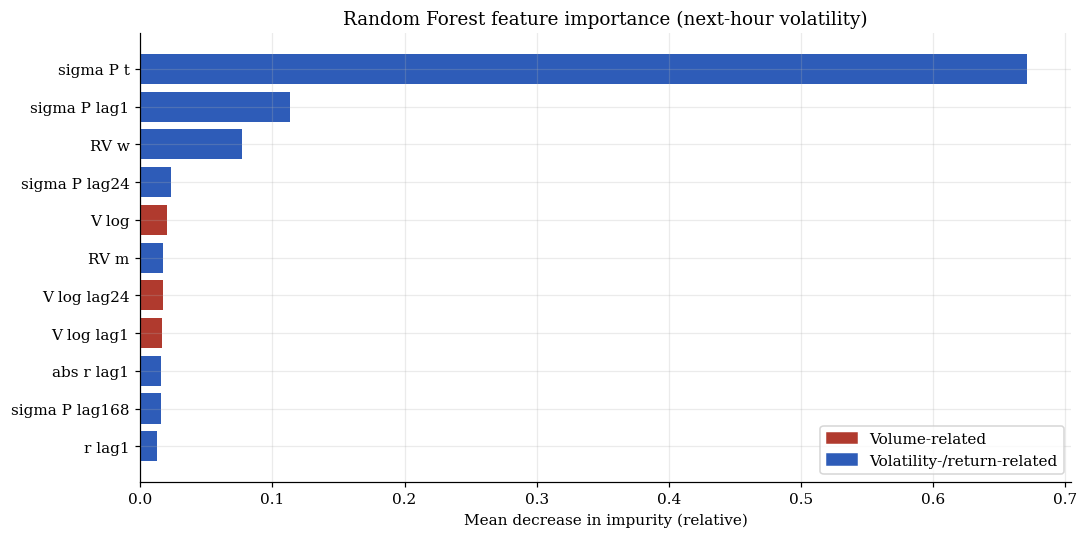


Feature importances (sorted):
  sigma_P_t             0.6709
  sigma_P_lag1          0.1131
  RV_w                  0.0771
  sigma_P_lag24         0.0236
  V_log                 0.0203
  RV_m                  0.0172
  V_log_lag24           0.0169
  V_log_lag1            0.0165
  abs_r_lag1            0.0159
  sigma_P_lag168        0.0154
  r_lag1                0.0131

Volume-feature importance total: 0.054


In [41]:
importances = pd.Series(rf_full.feature_importances_, index=feature_cols).sort_values()
vol_mask = importances.index.str.contains('V_log')
colors = ['#B03A2E' if v else '#2E5CB8' for v in vol_mask]

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh([f.replace('_', ' ') for f in importances.index], importances.values, color=colors)
ax.set_xlabel('Mean decrease in impurity (relative)')
ax.set_title('Random Forest feature importance (next-hour volatility)')
ax.legend(handles=[Patch(color='#B03A2E', label='Volume-related'), Patch(color='#2E5CB8', label='Volatility-/return-related')], loc='lower right')

plt.tight_layout()
plt.savefig('fig_importance.pdf')
plt.show()

print('\nFeature importances (sorted):')

for f, v in importances[::-1].items():
    print(f'  {f:<20s}  {v:.4f}')
print(f'\nVolume-feature importance total: {importances[vol_mask].sum():.3f}')


---
## Summary of findings

1. **H1 (MDH) supported.** $\hat\beta_1 = 0.00266$ (HAC SE 0.00008, $t = 33.4$, $p < 0.001$); 95% HAC CI $[+0.00251, +0.00282]$. $\Delta R^2 = +0.155$. The coefficient is positive and significant across four volatility proxies.

2. **H2 (SIAH) supported as predictive evidence.** Lagged log volume helps predict Parkinson volatility at every tested lag. At the one-day reference lag $p=24$, $F = 40.0$ and $p < 0.001$. The reverse direction is also significant, so the result should be read as lead-lag predictability rather than structural causality.

3. **H3 (out-of-sample forecasting) supported, but the gain is modest under the fair baseline.** When both Random Forest models receive current volatility $\sigma^P_t$, adding volume features improves test-set $R^2$ from $+0.343$ to $+0.350$. The bootstrap 95% CI for $\Delta R^2 = +0.007$ is $[+0.0046, +0.0102]$, excluding zero.

**Overall conclusion:** trading volume is a useful explanatory and predictive signal for short-term Bitcoin volatility. The strongest evidence is the contemporaneous H1 association; H2 adds Granger predictability rather than structural causality; H3 shows that volume still adds a small but measurable out-of-sample improvement after controlling for current and lagged volatility.
